# **Meng Import library yang dibutuhkan**

In [1]:
# import data handling tools
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# import Deep learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# **Meng ekstrak file .zip**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#Meng ekstrak file data.zip
import zipfile
import os
local_zip = '/content/drive/MyDrive/weather.zip'
zip_ref = zipfile.ZipFile(local_zip,'r')
zip_ref.extractall('/content/')
zip_ref.close()

# **MEMPERSIAPKAN DATA**

In [4]:
data_dir = '/content/weather'
target_size = (150, 150)
classes = 3

file_name = []
tag = []
full_path = []
for path, subdirs, files in os.walk(data_dir):
    for name in files:
        full_path.append(os.path.join(path, name))
        tag.append(path.split('/')[-1])
        file_name.append(name)

# memasukan variabel yang sudah dikumpulkan pada looping di atas menjadi sebuah dataframe agar rapih
df = pd.DataFrame({"path":full_path,'file_name':file_name,"tag":tag})
df.groupby(['tag']).size()

df.head()

,path,file_name,tag
0,/content/weather/rainy/rainy (155).jpg,rainy (155).jpg,rainy
1,/content/weather/rainy/rainy (383).jpg,rainy (383).jpg,rainy
2,/content/weather/rainy/rainy (281).jpg,rainy (281).jpg,rainy
3,/content/weather/rainy/rainy (354).jpg,rainy (354).jpg,rainy
4,/content/weather/rainy/rainy (205).jpg,rainy (205).jpg,rainy


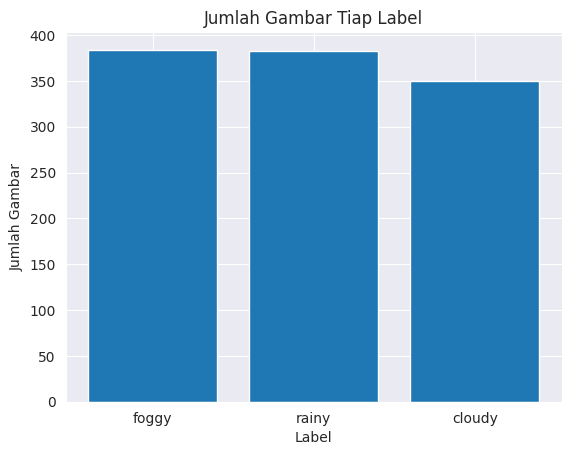

In [5]:
# Menghitung jumlah gambar per label
number_label = df['tag'].value_counts()

# Visualisasi jumlah gambar tiap label
plt.bar(number_label.index, number_label.values)
plt.title('Jumlah Gambar Tiap Label')
plt.xlabel('Label')
plt.ylabel('Jumlah Gambar')
plt.show()

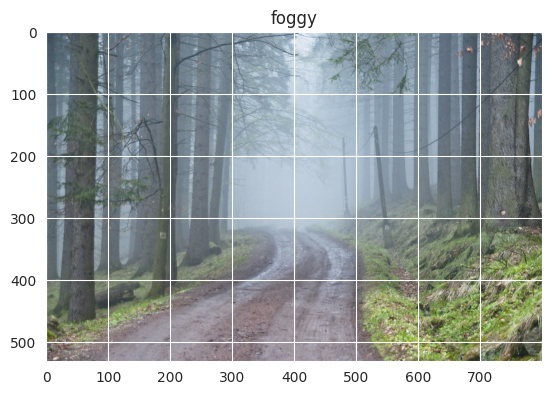

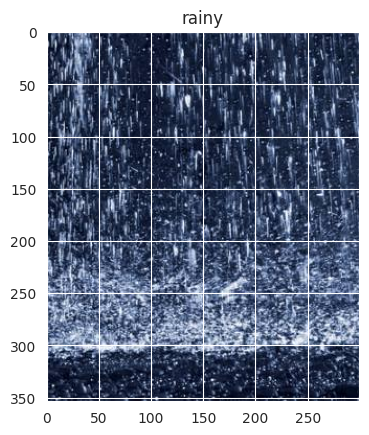

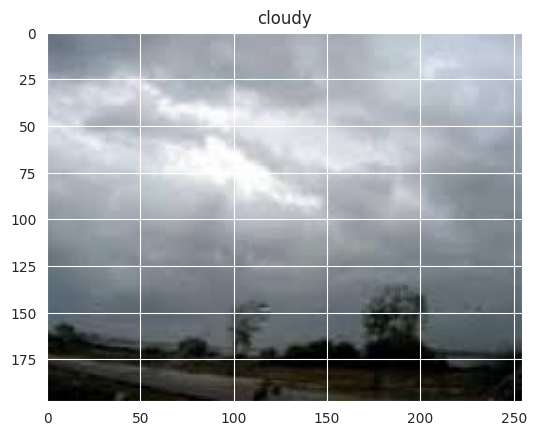

In [6]:
# Menampilkan sampel gambar dari tiap kelas
img_each_class = 1
img_samples = {}
classes = list(number_label.keys())

for c in classes:
    temp = os.listdir(os.path.join(data_dir, c))[:img_each_class]
    for item in temp:
        img_path = os.path.join(data_dir, c, item)
        img_samples[c] = img_path

for i in img_samples:
    fig = plt.gcf()
    img = mpimg.imread(img_samples[i])
    plt.title(i)
    plt.imshow(img)
    plt.show()

#**MEMBAGI DATA MENJADI DATA TRAIN 80% DAN DATA TEST 20%**

In [25]:
# Menentukan variabel X dan y
X = df['path']
y = df['tag']

# Membagi data menjadi data train dan test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# kemudian data test dibagi menjadi 2 sehingga menjadi data test dan data validation.
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

In [26]:
# menyatukan kedalam masing-masing dataframe
df_train = pd.DataFrame({'path':X_train,
                         'tag':y_train,
                         'set':'train'})

df_test = pd.DataFrame({'path':X_test,
                        'tag':y_test,
                        'set':'test'})

df_val = pd.DataFrame({'path':X_val,
                       'tag':y_val,
                       'set':'validation'})

df_all = pd.concat([df_train, df_test, df_val]).reset_index(drop=True)


print('Total image          : ', len(df_all))
print('Total train image    : ', len(df_train))
print('Total test image     : ', len(df_test))
print('Total validasi image : ', len(df_val))

Total image          :  1117
Total train image    :  893
Total test image     :  112
Total validasi image :  112


# **MERAPIHKAN KE FOLDER SET MASING - MASING**

In [27]:
import shutil
from tqdm.notebook import tqdm as tq

datasource_path = '/content/weather'
dataset_path = 'dataset/'

for index, row in tq(df_all.iterrows()):

    #detect filepath
    file_path = row['path']
    if os.path.exists(file_path) == False:
            file_path = os.path.join(datasource_path,row['tag'],row['image'].split('.')[0])

    #make folder destination dirs
    if os.path.exists(os.path.join(dataset_path,row['set'],row['tag'])) == False:
        os.makedirs(os.path.join(dataset_path,row['set'],row['tag']))

    #define file dest
    destination_file_name = file_path.split('/')[-1]
    file_dest = os.path.join(dataset_path,row['set'],row['tag'],destination_file_name)

    #copy file from source to dest
    if os.path.exists(file_dest) == False:
        shutil.copy2(file_path,file_dest)

0it [00:00, ?it/s]

# **LATIH DATA DAN DATA AUGMENTASI**

In [28]:
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 40,
    horizontal_flip = True,
    vertical_flip = True,
    shear_range = 0.2,
    fill_mode = 'nearest',
    zoom_range = 0.2,
    width_shift_range = 0.2,
    height_shift_range = 0.2
)


val_datagen = ImageDataGenerator(
    rescale = 1./255
)

In [29]:
train_generator= train_datagen.flow_from_directory(
    'dataset/train/',
    target_size=target_size,
    color_mode='rgb',
    class_mode='categorical',
    shuffle = True,
    batch_size = 32)

val_generator= val_datagen.flow_from_directory(
    'dataset/validation/',
    target_size=target_size,
    color_mode='rgb',
    class_mode='categorical',
    shuffle = True,
    batch_size = 32)

Found 1005 images belonging to 3 classes.
Found 137 images belonging to 3 classes.


# **MEMBANGUN MODEL**

In [70]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(150,150,3), padding='same'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(32, (3,3), activation = 'relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Flatten(),
    # tf.keras.layers.Dense(64, activation='relu'),
    # tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(3, activation='softmax')
])

In [71]:
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_12 (Conv2D)          (None, 150, 150, 16)      448       
                                                                 
 max_pooling2d_12 (MaxPooli  (None, 75, 75, 16)        0         
 ng2D)                                                           
                                                                 
 conv2d_13 (Conv2D)          (None, 75, 75, 32)        4640      
                                                                 
 max_pooling2d_13 (MaxPooli  (None, 37, 37, 32)        0         
 ng2D)                                                           
                                                                 
 conv2d_14 (Conv2D)          (None, 37, 37, 64)        18496     
                                                                 
 max_pooling2d_14 (MaxPooli  (None, 18, 18, 64)       

In [53]:
# class myCallback(tf.keras.callbacks.Callback):
#     def on_epoch_end(self, epoch, logs=None):
#         if logs is None:
#             logs = {}
#         accuracy = logs.get('accuracy')
#         val_accuracy = logs.get('val_accuracy')
#         if accuracy is not None and val_accuracy is not None:
#             if accuracy > 0.83 and val_accuracy > 0.83:
#                 print("\nTraining selesai!")
#                 self.model.stop_training = True

In [72]:
model.compile(
    optimizer = 'Nadam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

In [73]:
history = model.fit(
    train_generator,
    # steps_per_epoch=5,
    epochs=20,
    validation_data=val_generator,
    # validation_steps=5,
    verbose=1,
    # callbacks=[myCallback()]
)

Epoch 1/20
32/32 [==============================] - 36s 1s/step - loss: 1.0609 - accuracy: 0.4149 - val_loss: 0.9151 - val_accuracy: 0.6131
Epoch 2/20
32/32 [==============================] - 35s 1s/step - loss: 0.9191 - accuracy: 0.5652 - val_loss: 0.7505 - val_accuracy: 0.7080
Epoch 3/20
32/32 [==============================] - 32s 998ms/step - loss: 0.7937 - accuracy: 0.6517 - val_loss: 0.7679 - val_accuracy: 0.7299
Epoch 4/20
32/32 [==============================] - 32s 991ms/step - loss: 0.7296 - accuracy: 0.7154 - val_loss: 0.6456 - val_accuracy: 0.7956
Epoch 5/20
32/32 [==============================] - 33s 1s/step - loss: 0.6629 - accuracy: 0.7284 - val_loss: 0.7446 - val_accuracy: 0.7080
Epoch 6/20
32/32 [==============================] - 33s 1s/step - loss: 0.6314 - accuracy: 0.7373 - val_loss: 0.7905 - val_accuracy: 0.7518
Epoch 7/20
32/32 [==============================] - 37s 1s/step - loss: 0.5461 - accuracy: 0.7841 - val_loss: 0.4538 - val_accuracy: 0.8467
Epoch 8/20
32/

In [74]:
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

best_epoch = val_accuracy.index(max(val_accuracy)) + 1  # Add 1 because epochs are 1-indexed

print(f"Best Accuracy: {accuracy[best_epoch-1]:.4f} at Epoch {best_epoch}")
print(f"Best Validation Accuracy: {val_accuracy[best_epoch-1]:.4f} at Epoch {best_epoch}")

Best Accuracy: 0.8697 at Epoch 18
Best Validation Accuracy: 0.9270 at Epoch 18


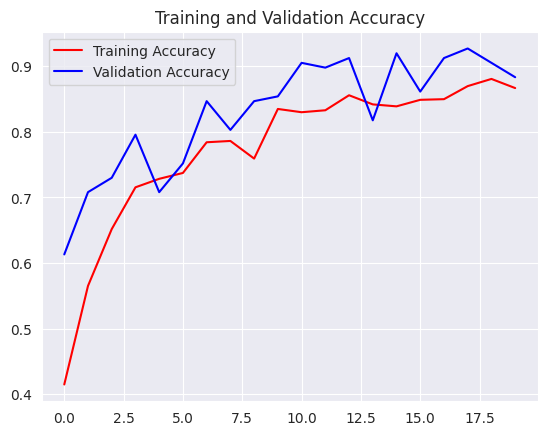

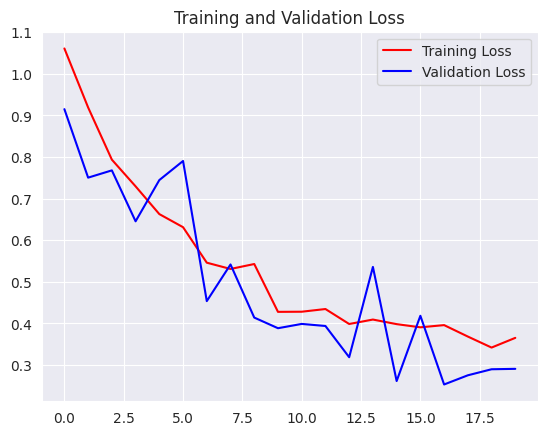

In [75]:
%matplotlib inline
import matplotlib.image as mpimg

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label = 'Training Accuracy')
plt.plot(epochs, val_acc, 'b', label = 'Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc = 'best')
plt.show()

plt.plot(epochs, loss, 'r', label = 'Training Loss')
plt.plot(epochs, val_loss, 'b', label = 'Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc = 'best')
plt.show()

In [76]:
val_loss, val_accuracy = model.evaluate(val_generator)

5/5 [==============================] - 2s 263ms/step - loss: 0.2910 - accuracy: 0.8832


# **TESTING DATA**

In [77]:
test_datagen = ImageDataGenerator(
    rescale = 1./255
)

test_generator= test_datagen.flow_from_directory(
    'dataset/test/',
    target_size=(150,150),
    shuffle = False,
    batch_size = 32)

test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy : {:.2f}%".format(test_acc * 100))
print("Test Loss     : {:.3f}".format(test_loss))

Found 138 images belonging to 3 classes.
5/5 [==============================] - 2s 378ms/step - loss: 0.2916 - accuracy: 0.8696
Test Accuracy : 86.96%
Test Loss     : 0.292


Saving kabut.jpg to kabut.jpg
1/1 [==============================] - 0s 26ms/step
kabut.jpg
Foggy Image


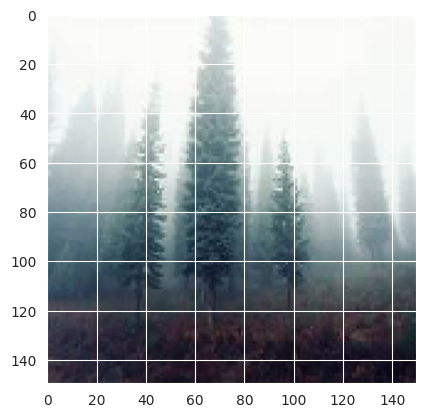

In [82]:
from keras.preprocessing import image
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():

  path = fn
  img = image.load_img(path, target_size =(150,150))
  imgplot = plt.imshow(img)
  x = image.img_to_array(img)
  x = np.expand_dims(x, axis=0)

  images = np.vstack([x])
  classes = model.predict(images, batch_size=10)

  print(fn)
  if classes[0][0] == 1:
      print('Cloudy Image')
  elif classes[0][1] == 1:
      print('Foggy Image')
  elif classes[0][2] == 1:
      print('Rainy Image')

# **MENGEVALUASI MODEL**

In [83]:
predictions = model.predict(val_generator)
predicted_classes = np.argmax(predictions, axis=1)

5/5 [==============================] - 1s 243ms/step


In [84]:
# Menghitung Confusion Matrix dan Classification Report
true_classes = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

conf_matrix = confusion_matrix(true_classes, predicted_classes)
class_report = classification_report(true_classes, predicted_classes, target_names=class_labels)

# Display the results
print("\nClassification Report:")
print(class_report)

print(f'Validation Accuracy: {val_accuracy * 100}%')


Classification Report:
              precision    recall  f1-score   support

      cloudy       0.27      0.24      0.26        37
       foggy       0.44      0.42      0.43        52
       rainy       0.35      0.40      0.37        48

    accuracy                           0.36       137
   macro avg       0.35      0.35      0.35       137
weighted avg       0.36      0.36      0.36       137

Validation Accuracy: 88.32116723060608%


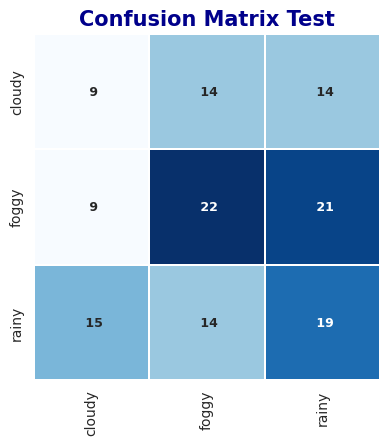

In [85]:
fig,ax = plt.subplots(figsize = (10,4.5))
sns.heatmap(conf_matrix,
            cmap = 'Blues',
            annot = True,
            annot_kws = {"fontsize":9, "fontweight":"bold"},
            linewidths = 1.2,
            fmt = ' ',
            linecolor = "white",
            square = True,
            xticklabels = class_labels,
            yticklabels = class_labels,
            cbar = False,
            ax = ax)
ax.set_title("Confusion Matrix Test", fontsize = 15, fontweight = "bold", color = "darkblue")
ax.tick_params('x',rotation = 90)
fig.show()

## SAVE MODEL

In [86]:
model.save('model.h5')
print('model saved as model.h5')

model saved as model.h5
